# importing the libraries

In [24]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchaudio.transforms as T
import torchaudio
import math
from pathlib import Path
import os
import sys
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import time


import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torchaudio")

# Check if __file__ exists (it won't in Jupyter)
try:
    current_dir = Path(__file__).parent
except NameError:
    # If in Jupyter, use the current working directory
    current_dir = Path(os.getcwd())

# Add project root to Python path
project_root = current_dir.parent.parent.parent
sys.path.insert(0, str(project_root))

from src.preprocessing.audio_utils import load_audio


# Device configuration (for your MacBook)
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✅ Using Apple Silicon GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✅ Using NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("⚠️ Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


✅ Using Apple Silicon GPU
PyTorch version: 2.10.0
Device: mps


# loading the dataset

In [25]:
class SpeakerDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_path, limit=None):
        # Load manifest JSON
        # Store all entries as self.data
        with open(manifest_path, "r") as f:
            full_data = json.load(f)
        
        if limit:
            self.data = full_data[:limit]
        else:
            self.data = full_data
    
    def __len__(self):
        # Return number of samples
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get entry at index idx
        # Load audio from disk
        # Extract features
        # Get label (num_speakers - 1)
        # Return (features, label)
        entry = self.data[idx]
        mixture_path = Path(entry['mixture_path'])
        mixture_audio, _ = load_audio(mixture_path)
        mixture_tensor = torch.from_numpy(mixture_audio)
        
        max_len = 480000 # 30 seconds at 16kHz
        
        if mixture_tensor.size(0) > max_len:
            # Truncate if too long
            mixture_tensor = mixture_tensor[:max_len]
        else:
            # Pad with zeros if too short
            padding = max_len - mixture_tensor.size(0)
            mixture_tensor = torch.nn.functional.pad(mixture_tensor, (0, padding))
        
        mixture_tensor = mixture_tensor.unsqueeze(0)
        
        speaker_count = int(entry['num_speakers']) - 1
        label_tensor = torch.tensor(speaker_count, dtype=torch.long)
        
        return mixture_tensor, label_tensor

In [26]:
train_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "train" / "train_manifest.json"
train_dataset = SpeakerDataset(train_manifest_path)
print(len(train_dataset))

val_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "val" / "val_manifest.json"
val_dataset = SpeakerDataset(val_manifest_path, 2000)
print(len(val_dataset))

10000
2000


In [27]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

In [28]:
audio = train_dataset[0][0][0]
print(len(audio))
print(audio.shape)

480000
torch.Size([480000])


# feature extraction

In [29]:
class features:
    def __init__(self, n_fft=400, hop_length=160, sample_rate=16000, n_mels=80, device='cpu'):
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.device = device
        self.torch_lmf = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=n_mels,
            center=False,
        ).to(self.device)
    
    def hand_crafted(self, batch):
        mean = torch.mean(batch, dim=-1)
        std = torch.std(batch, dim=-1)
        max_val = torch.max(batch, dim=-1).values
        min_val = torch.min(batch, dim=-1).values
        energy = torch.mean(batch ** 2, dim=-1)
        
        features = torch.stack([mean, std, max_val, min_val, energy], dim=-1)
        
        return features.view(batch.shape[0], -1).to(self.device)
    
    def raw_features(self, batch, max_samples=100000):
        num_samples = batch.shape[-1] - (max_samples - 1)
        random_start = torch.randint(0, num_samples, (1,)).item()
        
        if batch.dim() == 3:
            batch = batch.squeeze(1)
        
        return batch[:, random_start:random_start + max_samples].to(self.device)
    
    def stft_features(self, batch):
        if batch.dim() == 3:
            batch = batch.squeeze(1)
            
        dft = torch.stft(
            batch, 
            self.n_fft, 
            self.hop_length, 
            return_complex=True,
            window=torch.hann_window(self.n_fft).to(device=batch.device),
            center=False
        )    
        magnitude = torch.abs(dft)
        return magnitude.to(self.device)
    
    def torchLMF(self, batch):
        if batch.dim() == 3:
            batch = batch.squeeze(1)
        
        mel_spec = self.torch_lmf(batch)
        log = torch.log(mel_spec + 1e-8)
        
        return log.to(self.device)

In [30]:
print(device)
feature_extractor = features(device=device)
batch_audio, _ = next(iter(train_loader))

batch_audio = batch_audio.to(device)

print(batch_audio.shape)  # Should be (32, 1, 480000)

mps
torch.Size([32, 1, 480000])


In [31]:
print("Testing feature extraction on a batch of audio...")

features_list = feature_extractor.hand_crafted(batch_audio)
print(features_list.shape)  # Should be (32, 5)

Testing feature extraction on a batch of audio...
torch.Size([32, 5])


In [32]:
print("Testing raw feature extraction on a batch of audio...")

features_list = feature_extractor.raw_features(batch_audio)
print(features_list.shape)  # Should be (32, 10000)

Testing raw feature extraction on a batch of audio...
torch.Size([32, 100000])


In [33]:
print("Testing STFT feature extraction on a batch of audio...")

features_list = feature_extractor.stft_features(batch_audio)
print(features_list.shape) 

Testing STFT feature extraction on a batch of audio...
torch.Size([32, 201, 2998])


/Users/apple/Documents/programing/projects/voice_isolation/.venv/lib/python3.10/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 2998, 201]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


In [34]:
print("Testing torchLMF feature extraction on a batch of audio...")

features_list = feature_extractor.torchLMF(batch_audio)
print(features_list.shape)  

Testing torchLMF feature extraction on a batch of audio...
torch.Size([32, 80, 2998])


# model architecture

In [35]:
class SpeakerCounterMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
    
    def forward(self, x):
        return self.model(x)


# training loop

In [36]:
class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.should_stop = False
    
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.counter = 0
            self.best_loss = val_loss
            self.should_stop = False # improvement 
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            else: 
                self.should_stop = False
        
        return self.should_stop

def compute_accuracy(predictions, labels):
    """
    predictions: (batch_size, 3) logits
    labels: (batch_size,) true classes
    
    Returns: accuracy as percentage
    """
    predicted_classes = torch.argmax(predictions, dim=1)
    correct = (predicted_classes == labels).sum().item()
    total = labels.size(0)
    return 100.0 * correct / total

In [37]:
def train(model, feature_type="hand_crafted", device='cpu'):
    # --- PHASE 1: SETUP ---
    if feature_type not in ["hand_crafted", "raw", "stft", "torchLMF"]:
        raise ValueError("Invalid feature type.")
    
    feature_extractor = features(device=device)
    feature_extractor.torch_lmf.to(device)
    
    # Checkpoints setup
    checkpoint_dir = Path("checkpoints")
    checkpoint_dir.mkdir(exist_ok=True)
    checkpoint_path = checkpoint_dir / f"checkpoint_{feature_type}.pt"
    
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, min_lr=1e-6)
    early_stop = EarlyStopping(patience=5, min_delta=0.001)
    
    num_epochs = 50
    best_val_loss = float('inf')
    history = {'train_losses': [], 'val_losses': [], 'train_accs': [], 'val_accs': [], 'epoch_times': []}
    
    for epoch in range(num_epochs):
        # --- PHASE 2: TRAINING ---
        epoch_start = time.time()
        model.train()
        train_loss, train_acc = 0.0, 0.0
        train_loader_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        
        for batch_audio, batch_labels in train_loader_pbar:
            batch_audio, batch_labels = batch_audio.to(device), batch_labels.to(device)
            
            # Feature Extraction Logic (The "Wrapper" Logic)
            if feature_type == "hand_crafted": feats = feature_extractor.hand_crafted(batch_audio)
            elif feature_type == "raw": feats = feature_extractor.raw_features(batch_audio)
            elif feature_type == "stft": feats = feature_extractor.stft_features(batch_audio).mean(dim=-1)
            elif feature_type == "torchLMF": feats = feature_extractor.torchLMF(batch_audio).mean(dim=-1)
            
            # Ensure 2D: (Batch, Features)
            feats = feats.reshape(feats.size(0), -1)
            
            # Standard Forward/Backward
            optimizer.zero_grad()
            outputs = model(feats)
            loss = F.cross_entropy(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_acc += compute_accuracy(outputs, batch_labels)
            
            train_loader_pbar.set_postfix(loss=f"{loss.item():.4f}")
        
        # --- PHASE 3: VALIDATION ---
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        val_loader_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
        
        with torch.no_grad():
            for batch_audio, batch_labels in val_loader_pbar:
                batch_audio, batch_labels = batch_audio.to(device), batch_labels.to(device)
                
                # Repeat feature logic for validation
                if feature_type == "hand_crafted": feats = feature_extractor.hand_crafted(batch_audio)
                elif feature_type == "raw": feats = feature_extractor.raw_features(batch_audio)
                elif feature_type == "stft": feats = feature_extractor.stft_features(batch_audio).mean(dim=-1)
                elif feature_type == "torchLMF": feats = feature_extractor.torchLMF(batch_audio).mean(dim=-1)
                
                feats = feats.reshape(feats.size(0), -1)
                outputs = model(feats)
                loss = F.cross_entropy(outputs, batch_labels)
                
                val_loss += loss.item()
                val_acc += compute_accuracy(outputs, batch_labels)
                
                val_loader_pbar.set_postfix(val_loss=f"{loss.item():.4f}")
        
        # Average Metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_train_acc = train_acc / len(train_loader)
        avg_val_acc = val_acc / len(val_loader)
        
        # Update History & Scheduler
        history['train_losses'].append(avg_train_loss)
        history['val_losses'].append(avg_val_loss)
        history['train_accs'].append(avg_train_acc)
        history['val_accs'].append(avg_val_acc)
        scheduler.step(avg_val_loss)
        
        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({'model_state_dict': model.state_dict()}, checkpoint_path)
            status = f"New Best: {avg_val_loss:.4f}"
        else:
            status = "No Improvement"
        
        epoch_time = time.time() - epoch_start
        history['epoch_times'].append(epoch_time)
        
        if early_stop(avg_val_loss):
            print(f"\n Early stopping triggered at epoch {epoch+1}")
            break
            
    return history

In [38]:
results = {}

In [39]:
print("Starting training with hand-crafted features...")
results['hand_crafted'] = train(SpeakerCounterMLP(input_size=5).to(device), feature_type="hand_crafted", device=device)

Starting training with hand-crafted features...



 Early stopping triggered at epoch 13


In [40]:
print("Starting training with raw audio features...")
results['raw'] = train(SpeakerCounterMLP(input_size=100000).to(device), feature_type="raw", device=device)

Starting training with raw audio features...



 Early stopping triggered at epoch 9


In [41]:
print("Starting training with STFT features...")
results['stft'] = train(SpeakerCounterMLP(input_size=201).to(device), feature_type="stft", device=device)

Starting training with STFT features...


Epoch 1/50 [Val]:  98%|█████████▊| 62/63 [00:09<00:00,  6.94it/s, val_loss=0.5981]/Users/apple/Documents/programing/projects/voice_isolation/.venv/lib/python3.10/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 2998, 201]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]
                                                                                   


 Early stopping triggered at epoch 12


In [42]:
print("Starting training with torchLMF features...")
results['torchLMF'] = train(SpeakerCounterMLP(input_size=80).to(device), feature_type="torchLMF", device=device)

Starting training with torchLMF features...


Epoch 1/50 [Train]:   0%|          | 0/312 [00:00<?, ?it/s]


 Early stopping triggered at epoch 6


# comparision

In [43]:
def print_comparison_table(results):
    # Updated header with Time column
    print(f"{'Feature Type':<15} | {'Val Loss':<9} | {'Val Acc':<9} | {'Train Acc':<10} | {'Avg Epoch Time':<10}")
    print("-" * 75)
    
    for f_type, metrics in results.items():
        v_loss = metrics['val_losses'][-1]
        v_acc  = metrics['val_accs'][-1]
        t_acc  = metrics['train_accs'][-1]
        
        # Calculate average time per epoch
        times = metrics.get('epoch_times', [])
        avg_time = sum(times) / len(times) if times else 0.0
        
        print(f"{f_type:<15} | {v_loss:<9.4f} | {v_acc:<9.2f}% | {t_acc:<10.2f}% | {avg_time:<10.2f}s")

In [44]:
def plot_training_results(results):
    # Increased to 3 subplots to accommodate Time
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    
    for f_type, metrics in results.items():
        epochs = range(1, len(metrics['train_losses']) + 1)
        
        # Plot Loss
        ax1.plot(epochs, metrics['val_losses'], label=f'{f_type}')
        ax1.set_title('Validation Loss')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot Accuracy
        ax2.plot(epochs, metrics['val_accs'], label=f'{f_type}')
        ax2.set_title('Validation Accuracy')
        ax2.set_xlabel('Epochs')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # New: Plot Epoch Times
        if 'epoch_times' in metrics:
            ax3.plot(epochs, metrics['epoch_times'], label=f'{f_type}')
            ax3.set_title('Epoch Duration')
            ax3.set_xlabel('Epochs')
            ax3.set_ylabel('Time (seconds)')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [45]:
print_comparison_table(results)

Feature Type    | Val Loss  | Val Acc   | Train Acc  | Avg Epoch Time
---------------------------------------------------------------------------
hand_crafted    | 0.7007    | 61.31    % | 59.31     % | 42.79     s
raw             | 0.6909    | 53.82    % | 53.55     % | 43.42     s
stft            | 0.8462    | 64.93    % | 74.73     % | 55.12     s
torchLMF        | 0.6154    | 66.87    % | 69.79     % | 57.63     s


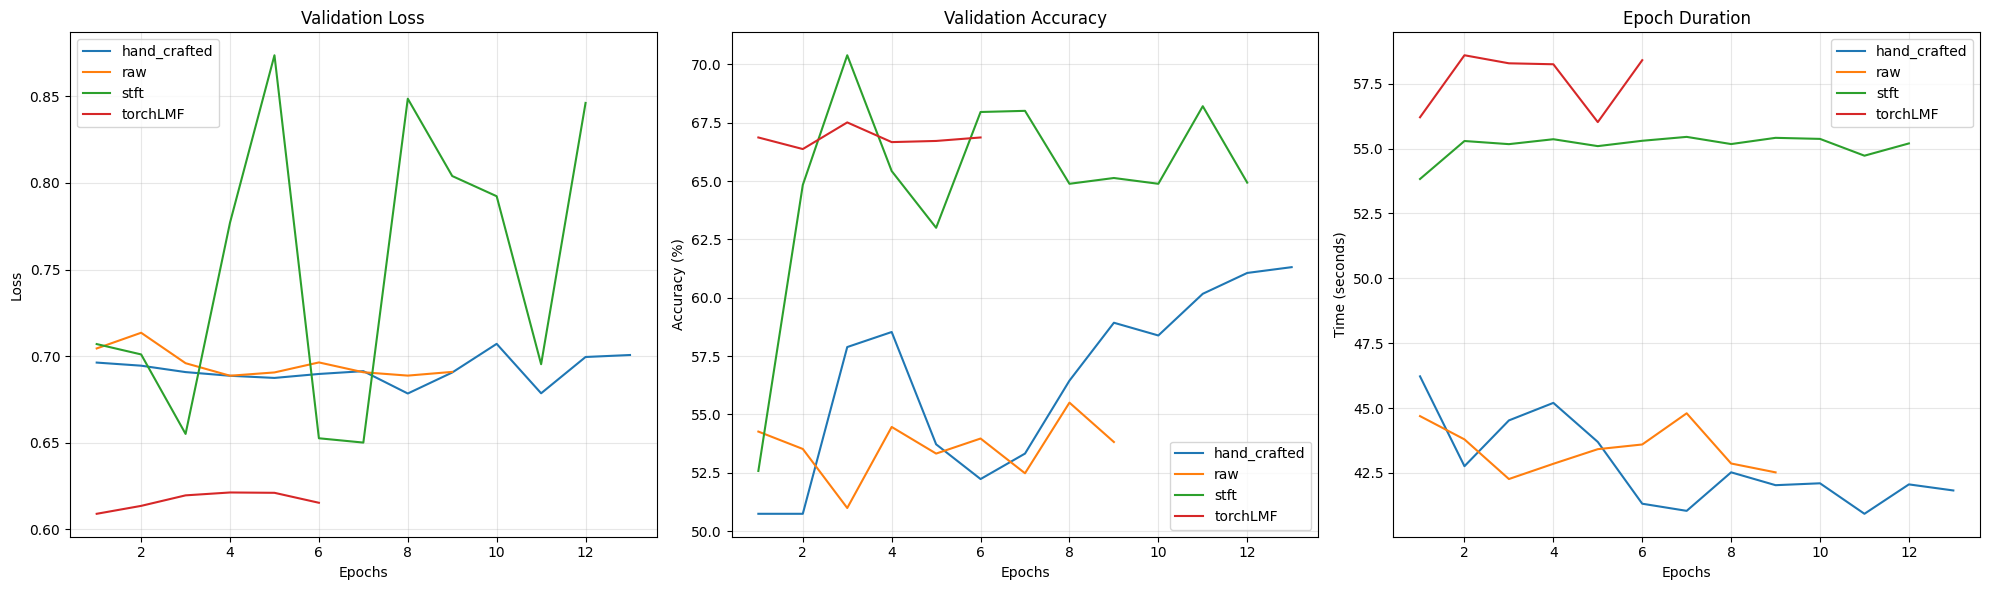

In [46]:
plot_training_results(results)